## How to load PDFs

### simple pdf loader

In [1]:
from langchain_community.document_loaders import PyPDFLoader

In [2]:
file_path = '''./split_pdf/merged_经济学百科.pdf'''

In [3]:
# loader = PyPDFLoader(file_path)
# pages = []
# async for page in loader.alazy_load():
#     pages.append(page)
# print(pages[6].page_content)

# Local parsing

In [4]:
import os
# use proxy
os.environ["https_proxy"] = 'http://127.0.0.1:7897'
os.environ["http_proxy"] = 'http://127.0.0.1:7897'
os.environ["all_proxy"] = 'socks5://127.0.0.1:7897'

# must download nltk before
# [nltk_data] Downloading package punkt to /home/zj/nltk_data...
# [nltk_data]   Unzipping tokenizers/punkt.zip.
# sudo apt-get install tesseract-ocr-chi-sim
# import nltk
# nltk.download('punkt')

In [5]:
from langchain_unstructured import UnstructuredLoader

loader = UnstructuredLoader(
    file_path=file_path,
    # need yolo_x_layout under the unstructuredio
    strategy="hi_res",
    # partition_via_api=True,
    # coordinates=True,
    languages=['chi_sim',], # specific ocr languages
)
docs = []
for doc in loader.lazy_load():
    docs.append(doc)

INFO: pikepdf C++ to Python logger bridge initialized
INFO: Reading PDF for file: ./split_pdf/merged_经济学百科.pdf ...


In [6]:
first_page_docs = [doc for doc in docs if doc.metadata.get("page_number") == 15]

table_of_contents = [doc for doc in docs if 2 <= doc.metadata.get("page_number") <= 7]
for doc in first_page_docs:
    print(doc.page_content)

引
12
呸

们 常 认 为 , 经 济 学 是 一 门 既 复杂又神秘的手科 它 与 人 此 , 没人会仇 一 己恒经济子o 人们 普 遍 认 为 , 只 有 商 业 、 金 融 以 及 政 府 方 面 的 专 业 人 士 才 精 通 经 济 学 。 然 而 , 人 们 越 来 越 意 识 到 经 济 学 对 我 们 的 经 济 收 入 和 健 康 生 活 的 重 耍 影 响 , 此 外 , 人们又一一经济还有 的 生 活 开 支 、 税 收 ,〖 等 方 面 颇 有 微 词 。 他 f 来 自 于 各 大 新 闻 对 某 一 事 件 的 集 报 道 , 有 时 , 人 们 也 会 在 餐 桌 或 者
留 根 经 济 学 中 , 希 望 、 信 心 与 科 学 的 狂 妄 、 对 尊 重 的 渴 望 平 存 。 一 一 美 算 加 拿 大 经 济 学 家 , 约 翰 * 肯 尼 斯 加 尔 布 雷 思 (1908-2006) 9

工 作 场 所 讨 论 这 些 话 题 。 从 某 种 意 , 我 们 确 实 都 对 经 济 学 感 兴 趣 。 我 们 用 来 论 述 对 某 一 事 件 看 法 的 论 点 , 经 济 学 家 同 样 也 会 引 用 。 因 此 , 多 懂 一 些 经 济 学 理 论 , 有 助 于 我 们 理 解 那 些 在 生 活 中 发 挥 重 要 作 用 的 经 济 原 则 。
新 闻 中 的 经 济 学
当 今 的 世 界 陷 入 了 明 显 的 经 济 混 乱 中 , 在 这 种 环 境 下 , 了 解 一 些 经 济 学 的 知 识 就 显 得 尤 为 重 要 。 经 济 新 闻 不 仅 是 在 报 纸 中 开 辟 一 个 专 栏 , 或 者 出 现 在 电 视 新 闻 中 的 桅 部 分 , 它 们 甚 至 会 经 常 出 现 在 各 大 媒 体 的 头 条 。 早 在 1997 年 , 美 国 共 和 党 政 治 活 动 策 略 家 罗 伯 特 * 蒂 特 ( Robert Teeter ) 就意识至丨 了它的 重 要 地 位 。 他 认 为 ,“ 电 视 对 政 治 的 报 道 越 来 越 少 , 对 选 举 的 报 道 也 越 来 越 少 , 因 为 推 动 一 个 国 家 发 展 的是经济字和绎济新闻 一 不 是 政 治

apt-get install poppler-utils
apt-get install tesseract-ocr

## Extracting tables and other structures

In [19]:
!pip install -qU matplotlib PyMuPDF pillow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docling-core 2.3.1 requires pillow<11.0.0,>=10.3.0, but you have pillow 11.0.0 which is incompatible.
docling-ibm-models 2.0.3 requires Pillow<11.0.0,>=10.0.0, but you have pillow 11.0.0 which is incompatible.
pyrobbot 0.7.7 requires httpx<0.27.0,>=0.26.0, but you have httpx 0.27.2 which is incompatible.
pyrobbot 0.7.7 requires pillow<11.0.0,>=10.2.0, but you have pillow 11.0.0 which is incompatible.
pyrobbot 0.7.7 requires tiktoken<0.7.0,>=0.6.0, but you have tiktoken 0.7.0 which is incompatible.
streamlit 1.38.0 requires pillow<11,>=7.1.0, but you have pillow 11.0.0 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import fitz
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image


def plot_pdf_with_boxes(pdf_page, segments):
    pix = pdf_page.get_pixmap()
    pil_image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(pil_image)
    categories = set()
    category_to_color = {
        "Title": "orchid",
        "Image": "forestgreen",
        "Table": "tomato",
    }
    for segment in segments:
        points = segment["coordinates"]["points"]
        layout_width = segment["coordinates"]["layout_width"]
        layout_height = segment["coordinates"]["layout_height"]
        scaled_points = [
            (x * pix.width / layout_width, y * pix.height / layout_height)
            for x, y in points
        ]
        box_color = category_to_color.get(segment["category"], "deepskyblue")
        categories.add(segment["category"])
        rect = patches.Polygon(
            scaled_points, linewidth=1, edgecolor=box_color, facecolor="none"
        )
        ax.add_patch(rect)

    # Make legend
    legend_handles = [patches.Patch(color="deepskyblue", label="Text")]
    for category in ["Title", "Image", "Table"]:
        if category in categories:
            legend_handles.append(
                patches.Patch(color=category_to_color[category], label=category)
            )
    ax.axis("off")
    ax.legend(handles=legend_handles, loc="upper right")
    plt.tight_layout()
    plt.show()


def render_page(doc_list: list, page_number: int, print_text=True) -> None:
    pdf_page = fitz.open(file_path).load_page(page_number - 1)
    page_docs = [
        doc for doc in doc_list if doc.metadata.get("page_number") == page_number
    ]
    segments = [doc.metadata for doc in page_docs]
    plot_pdf_with_boxes(pdf_page, segments)
    if print_text:
        for doc in page_docs:
            print(f"{doc.page_content}\n")

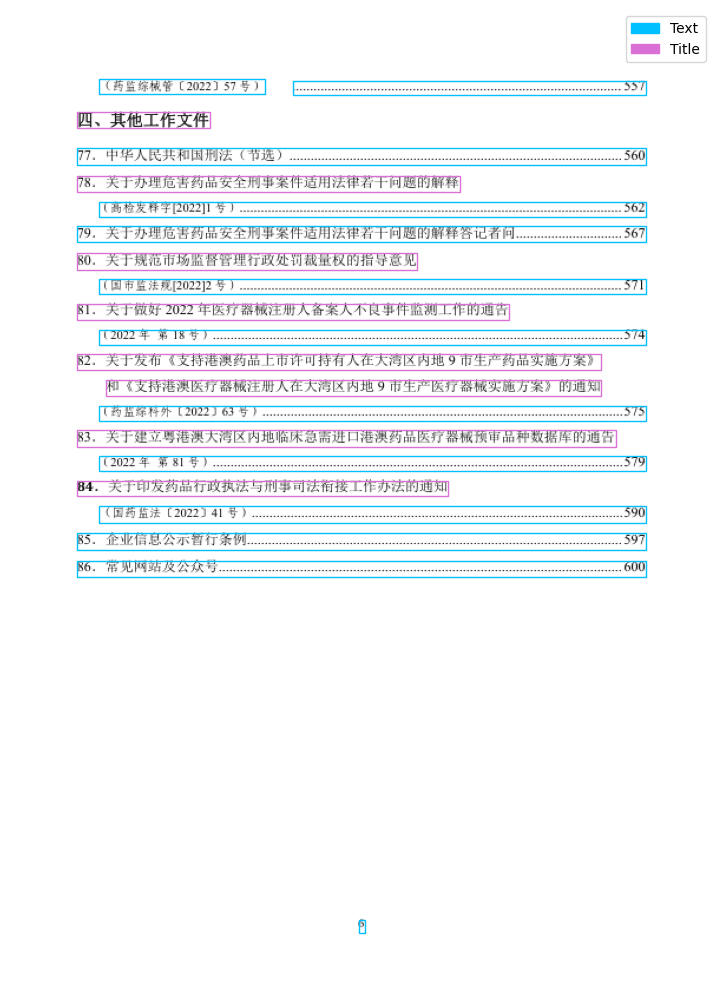

（药监综械管〔2022〕57 号）

............................................................................................. 557

四、其他工作文件

77．中华人民共和国刑法（节选）.............................................................................................. 560

78．关于办理危害药品安全刑事案件适用法律若干问题的解释

（高检发释字[2022]1 号）............................................................................................................ 562

79．关于办理危害药品安全刑事案件适用法律若干问题的解释答记者问.............................. 567

80．关于规范市场监督管理行政处罚裁量权的指导意见

（国市监法规[2022]2 号）............................................................................................................ 571

81．关于做好 2022 年医疗器械注册人备案人不良事件监测工作的通告

（2022 年 第 18 号）....................................................................................................................574

82．关于发布《支持港澳药品上市许可持有人在大湾区内地 9 市生产药品实施方案》

和《支持港澳医疗器械注册人在大湾区内地 9 市生产医疗器械实施方案》的通知

（药监综科外〔2022〕63 号）....................................................................................................

In [33]:
render_page(docs, 7)

In [ ]:
table_of_contents